# DELTA DIY MRI Workshop — Finding f0

**f0 is the Larmor frequency of your magnet, right now.** Every other calibration depends on
it. Transmit at the wrong frequency and the RF pulse excites weakly or not at all, the echo
is small or absent, and every downstream adjustment — RF amplitude, shim, gradients — is
calibrated against noise.

It is not a constant you look up. It follows the magnetic field, and on a permanent-magnet
low-field system the field follows **temperature**. A Halbach array drifts on the order of
hundreds of Hz per degree, so f0 measured this morning is not f0 now. This is why
`adj_frequency` is the first scan you run in a session, and why you re-run it after the
magnet has been working.

MRI4ALL finds f0 in **two stages**, because no single method does both jobs well:

| Stage | Method | Resolution | Purpose |
| --- | --- | --- | --- |
| 1. Coarse | Sweep transmit frequency, keep the step with the best SNR | the step size (kHz) | Find the peak at all |
| 2. Fine | FFT the echo, read the offset of the spectral peak | `1 / T_adc` (Hz) | Land on it precisely |

Stage 1 is `larmor_step_search`; stage 2 is `larmor_cal`, both in
`console/external/seq/adjustments_acq/calibration.py`.

This notebook builds the same spin echo the console uses, **simulates** the acquisition so
no scanner is needed, and runs both stages on the simulated data — recovering an f0 you
chose in advance, so you can check the answer.

**Prerequisites:** `01_setup_environment.ipynb`, and `03_MRI4all_seq_runner.ipynb` for the
`.seq` toolchain this notebook reuses. No scanner or Red Pitaya required.

## Cell 1 — Environment

Same setup as notebook 03: find the repo, give the console a writable base path, and
**append** `console/` to `sys.path` so the installed PyPulseq wins over the vendored copy.
See notebook 03 Cell 1 if any of that is unfamiliar.

In [1]:
# Cell 1 — Locate the console and import the toolchain

import os
import sys
from pathlib import Path

print("Cell 1 — Environment")
print("--------------------")

here = Path.cwd().resolve()
repo_root = None
for candidate in [here, *here.parents]:
    if (candidate / "console" / "external" / "flocra_pulseq").is_dir():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError(
        "Could not find the adelpha repo root from " + str(here) + ".\n"
        "Run this notebook from console/notebooks/ inside the repository."
    )

console_dir = repo_root / "console"
work_dir = Path.cwd() / "f0_output"
work_dir.mkdir(exist_ok=True)
os.environ.setdefault("MRI4ALL_BASE", str(work_dir / "mri4all"))
(Path(os.environ["MRI4ALL_BASE"]) / "logs").mkdir(parents=True, exist_ok=True)

if str(console_dir) not in sys.path:
    sys.path.append(str(console_dir))   # APPEND -- see notebook 03, Cell 1

import numpy as np
import matplotlib.pyplot as plt
import pypulseq as pp

print("Repo root   :", repo_root)
print("MRI4ALL_BASE:", os.environ["MRI4ALL_BASE"])
print("PyPulseq    :", Path(pp.__file__).parent)
print("\nPASS: environment ready.")

Cell 1 — Environment
--------------------
Repo root   : /home/jonathanmartin/Documents/postdoc-projects/DIY_MRI/adelpha
MRI4ALL_BASE: /home/jonathanmartin/Documents/postdoc-projects/DIY_MRI/adelpha/console/notebooks/f0_output/mri4all
PyPulseq    : /home/jonathanmartin/anaconda3/envs/adelpha/lib/python3.11/site-packages/pypulseq

PASS: environment ready.


## Cell 2 — The f0 currently on record

`LARMOR_FREQ` is what the scanner will transmit at until an adjustment scan replaces it. It
lives in `config_acq.json`, written by the console's adjustment scans and read back through
`external.seq.adjustments_acq.config`.

Treat the stored value as a **starting point for the search, not an answer.** That is
exactly how `larmor_step_search` uses it: as the centre of the sweep.

In [2]:
# Cell 2 — Read the stored Larmor frequency

print("Cell 2 — Stored calibration")
print("---------------------------")

import logging

logging.disable(logging.WARNING)   # silence the sequence-registry circular-import chatter
try:
    import external.seq.adjustments_acq.config as cfg
    from sequences.common.util import path as config_path

    LARMOR_FREQ_MHZ = float(cfg.LARMOR_FREQ)
    RF_MAX_HZ = float(cfg.RF_MAX)
    source = "config_acq.json"
except Exception as exc:
    LARMOR_FREQ_MHZ, RF_MAX_HZ = 15.52, 5.0e3
    config_path = "(not available)"
    source = f"fallback defaults ({type(exc).__name__})"
finally:
    logging.disable(logging.NOTSET)

print("Source        :", source)
print("Config file   :", config_path)
print(f"LARMOR_FREQ   : {LARMOR_FREQ_MHZ:.5f} MHz   <-- the current best guess")
print(f"RF_MAX        : {RF_MAX_HZ:.1f} Hz")
print()
print("This is where the search starts, not where it ends.")

Cell 2 — Stored calibration
---------------------------
Source        : config_acq.json
Config file   : /home/jonathanmartin/Documents/postdoc-projects/DIY_MRI/adelpha/console/notebooks/f0_output/mri4all/config/config_acq.json
LARMOR_FREQ   : 15.52000 MHz   <-- the current best guess
RF_MAX        : 10000.0 Hz

This is where the search starts, not where it ends.


## Cell 3 — The sequence: a plain spin echo

f0 is measured with the simplest thing that produces a signal — a 90°/180° spin echo, no
gradients. `console/sequences/adj_frequency.py` builds it with `make_rf_se.pypulseq_rfse`,
and this cell calls that same function, so the `.seq` here is the one the console would play.

Two parameters set the limits of everything that follows:

- **`ADC_duration`** fixes the frequency resolution. The FFT bin width is `1 / T_adc`, so a
  6400 µs readout resolves ~156 Hz and no better.
- **`ADC_samples`** with the duration fixes the dwell time, and `1 / dwell` is the total
  bandwidth you can see. Offsets outside `±1/(2·dwell)` alias.

Longer readout, finer resolution — until T2\* kills the echo and you are just measuring noise.

In [3]:
# Cell 3 — Build the spin echo the console uses for f0

print("Cell 3 — Build the adjustment sequence")
print("--------------------------------------")

TE_MS, TR_MS = 20, 250
ADC_SAMPLES, ADC_DURATION_US = 256, 6400

logging.disable(logging.WARNING)
try:
    from sequences.common import make_rf_se

    seq_path = work_dir / "adj_frequency.seq"
    built = make_rf_se.pypulseq_rfse(
        inputs={
            "TE": TE_MS, "TR": TR_MS, "NSA": 1,
            "ADC_samples": ADC_SAMPLES, "ADC_duration": ADC_DURATION_US,
            "FA1": 90, "FA2": 180,
        },
        check_timing=True,
        output_file=str(seq_path),
    )
finally:
    logging.disable(logging.NOTSET)

print("pypulseq_rfse ->", built)
if seq_path.is_file():
    print(f"Wrote {seq_path.name} ({seq_path.stat().st_size} bytes)")

# The numbers that bound the measurement.
T_ADC_S = ADC_DURATION_US * 1e-6
DWELL_S = T_ADC_S / ADC_SAMPLES

print()
print(f"  ADC samples      : {ADC_SAMPLES}")
print(f"  ADC duration     : {ADC_DURATION_US} us")
print(f"  dwell time       : {DWELL_S*1e6:.2f} us")
print(f"  FFT bin width    : {1/T_ADC_S:8.2f} Hz    <-- best fine resolution")
print(f"  total bandwidth  : {1/DWELL_S:8.0f} Hz    <-- offsets beyond +/- half of this alias")

Cell 3 — Build the adjustment sequence
--------------------------------------
pypulseq_rfse -> True
Wrote adj_frequency.seq (1255 bytes)

  ADC samples      : 256
  ADC duration     : 6400 us
  dwell time       : 25.00 us
  FFT bin width    :   156.25 Hz    <-- best fine resolution
  total bandwidth  :    40000 Hz    <-- offsets beyond +/- half of this alias


## Cell 4 — Simulating the scanner

There is no Red Pitaya attached, so we simulate what the receiver would return. The model is
deliberately simple but has the three features the algorithms actually depend on:

1. **The echo sits in the middle of the readout.** This matters more than it looks. The
   console estimates noise from the first and last 40% of the window
   (`get_freq_vals_from_echoes`), which is only valid if the echo is a narrow blip in the
   centre. Simulate an FID with its peak at t=0 instead and the SNR metric stops
   discriminating entirely — I tried, and the step search picks essentially at random.
2. **Off-resonance costs signal.** A block pulse of duration τ excites a band roughly
   `sinc(Δf·τ)` wide, so the further your transmit frequency is from f0, the smaller the echo.
   That falloff is the entire basis of the coarse search.
3. **Off-resonance rotates phase**, at exactly `Δf`. That is what the FFT reads in stage 2.

`F0_TRUE_MHZ` is the answer the notebook is trying to recover. Change it and rerun to
convince yourself nothing is hard-coded.

Each plotting cell starts with `%matplotlib inline` because importing the console config in
Cell 2 forces `matplotlib.use("Agg")` for headless operation — without re-asserting the
inline backend, `plt.show()` silently draws nothing. Notebook 03 Cell 5 explains why.

Cell 4 — Simulated acquisition
------------------------------
True f0 (hidden from the algorithms): 15.52370 MHz
Stored guess                        : 15.52000 MHz
Error to recover                    : +3700 Hz
Excitation bandwidth (1/RF duration): 10000 Hz


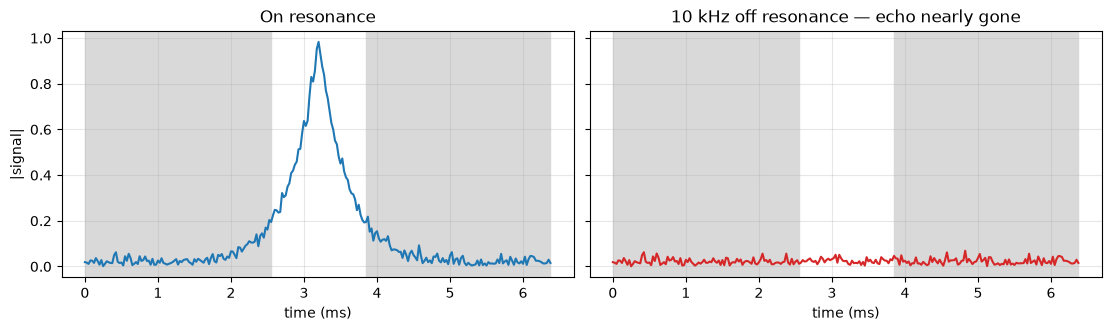

Shaded bands are the regions the console treats as noise (first and last 40%).


In [4]:
%matplotlib inline

# Cell 4 — A simulated receiver

print("Cell 4 — Simulated acquisition")
print("------------------------------")

# --- ground truth: the notebook must rediscover this -----------------------
F0_TRUE_MHZ = 15.5237
# ---------------------------------------------------------------------------

RF_DURATION_S = 100e-6      # block pulse -> ~1/RF_DURATION excitation bandwidth
T2_STAR_S = 400e-6          # echo width
NOISE_SIGMA = 0.02          # per quadrature

t = np.arange(ADC_SAMPLES) * DWELL_S
t_echo = T_ADC_S / 2        # spin echo peaks mid-readout


def acquire(f_tx_mhz, seed=0, noise_sigma=NOISE_SIGMA):
    """Return complex receive data for a transmit frequency, as run_pulseq would."""
    rng = np.random.default_rng(seed)
    delta_hz = (F0_TRUE_MHZ - f_tx_mhz) * 1e6
    excitation = abs(np.sinc(delta_hz * RF_DURATION_S))       # numpy sinc is normalised
    envelope = np.exp(-np.abs(t - t_echo) / T2_STAR_S)
    signal = excitation * envelope * np.exp(2j * np.pi * delta_hz * (t - t_echo))
    noise = noise_sigma * (rng.normal(size=ADC_SAMPLES) + 1j * rng.normal(size=ADC_SAMPLES))
    return signal + noise


print(f"True f0 (hidden from the algorithms): {F0_TRUE_MHZ:.5f} MHz")
print(f"Stored guess                        : {LARMOR_FREQ_MHZ:.5f} MHz")
print(f"Error to recover                    : {(F0_TRUE_MHZ - LARMOR_FREQ_MHZ)*1e6:+.0f} Hz")
print(f"Excitation bandwidth (1/RF duration): {1/RF_DURATION_S:.0f} Hz")

on_res = acquire(F0_TRUE_MHZ, seed=1)
off_res = acquire(F0_TRUE_MHZ - 0.010, seed=1)   # 10 kHz low

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True, sharey=True)
ax[0].plot(t * 1e3, np.abs(on_res)); ax[0].set_title("On resonance")
ax[1].plot(t * 1e3, np.abs(off_res), color="tab:red")
ax[1].set_title("10 kHz off resonance — echo nearly gone")
for a in ax:
    a.set_xlabel("time (ms)"); a.grid(alpha=0.3)
    a.axvspan(0, t[int(0.4*ADC_SAMPLES)]*1e3, color="0.85", zorder=0)
    a.axvspan(t[-int(0.4*ADC_SAMPLES)]*1e3, t[-1]*1e3, color="0.85", zorder=0)
ax[0].set_ylabel("|signal|")
plt.show()

print("Shaded bands are the regions the console treats as noise (first and last 40%).")

## Cell 5 — Stage 1: coarse step search

Sweep the transmit frequency across a grid and keep the step with the best SNR. This is
`larmor_step_search`, and the SNR metric below is `get_freq_vals_from_echoes` verbatim:

```
peak  = max(|signal|)
noise = mean of the first 40% and last 40% of |signal|, averaged
SNR   = peak / noise
```

Crude, but it only has to get within one step of f0. **The step size is the accuracy** — a
5 kHz grid cannot do better than ±2.5 kHz, and that is fine, because stage 2 fixes it.

The sweep has to be wide enough to contain the true f0 and fine enough that the excitation
profile has not fallen to nothing between steps. With a 100 µs pulse the usable window is
about ±10 kHz, so steps much coarser than that will step straight over the peak.

Cell 5 — Stage 1: coarse step search
------------------------------------
     frequency      SNR
  -----------------------
    15.4950 MHz     3.04
    15.5000 MHz     6.05
    15.5050 MHz     3.21
    15.5100 MHz     7.92
    15.5150 MHz     5.72
    15.5200 MHz    18.92
    15.5250 MHz    22.10   <-- best
    15.5300 MHz    13.24
    15.5350 MHz     3.89
    15.5400 MHz     7.64
    15.5450 MHz     3.39

Coarse estimate : 15.52500 MHz
True f0         : 15.52370 MHz
Error           : +1300 Hz   (grid is 5 kHz, so +/-2500 Hz is the floor)


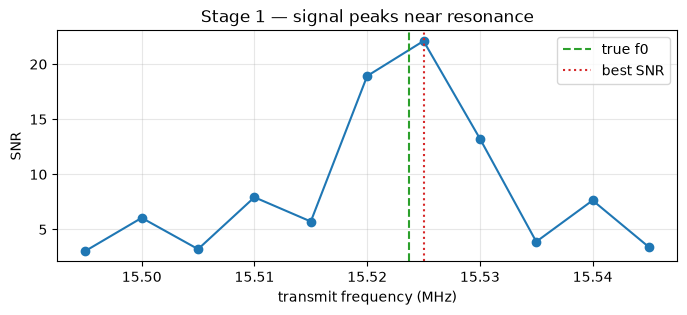

In [5]:
%matplotlib inline

# Cell 5 — Coarse search: sweep transmit frequency, keep the best SNR

print("Cell 5 — Stage 1: coarse step search")
print("------------------------------------")

STEPS = 11
STEP_BW_MHZ = 5e-3          # 5 kHz grid, as larmor_step_search defaults

search_center = LARMOR_FREQ_MHZ
swept_freqs = np.linspace(
    search_center - ((STEPS - 1) / 2 * STEP_BW_MHZ),
    search_center + ((STEPS - 1) / 2 * STEP_BW_MHZ),
    num=STEPS,
)


def snr_of(rx):
    """SNR exactly as get_freq_vals_from_echoes computes it."""
    abs_signal = np.abs(rx)
    n_points = int(0.4 * abs_signal.shape[0])
    peak_value = abs_signal.max()
    noise_level = (abs_signal[:n_points].mean() + abs_signal[-n_points:].mean()) / 2
    return (peak_value / noise_level) if noise_level else 0.0


snr_values = np.array([snr_of(acquire(f, seed=100 + i)) for i, f in enumerate(swept_freqs)])
best_index = int(np.argmax(snr_values))
coarse_f0 = swept_freqs[best_index]

print(f"  {'frequency':>12s}  {'SNR':>7s}")
print("  " + "-" * 23)
for f, s in zip(swept_freqs, snr_values):
    mark = "   <-- best" if f == coarse_f0 else ""
    print(f"  {f:9.4f} MHz  {s:7.2f}{mark}")

coarse_err = (coarse_f0 - F0_TRUE_MHZ) * 1e6
print()
print(f"Coarse estimate : {coarse_f0:.5f} MHz")
print(f"True f0         : {F0_TRUE_MHZ:.5f} MHz")
print(f"Error           : {coarse_err:+.0f} Hz   (grid is {STEP_BW_MHZ*1e3:.0f} kHz, so +/-{STEP_BW_MHZ*1e6/2:.0f} Hz is the floor)")

plt.figure(figsize=(8, 3))
plt.plot(swept_freqs, snr_values, "o-")
plt.axvline(F0_TRUE_MHZ, color="tab:green", ls="--", label="true f0")
plt.axvline(coarse_f0, color="tab:red", ls=":", label="best SNR")
plt.xlabel("transmit frequency (MHz)"); plt.ylabel("SNR"); plt.grid(alpha=0.3)
plt.legend(); plt.title("Stage 1 — signal peaks near resonance")
plt.show()

## Cell 6 — Stage 2: FFT the echo

Now transmit at the coarse estimate and read the residual offset out of the spectrum. If the
transmit frequency is wrong by `Δf`, the demodulated echo carries exactly that beat, and the
FFT peak sits at `Δf`.

This is the axis construction from `larmor_cal`, and the units are the part to get right:

```python
fft_bw = 1 / rx_t                                  # rx_t is the DWELL time
fft_x  = np.linspace(f_tx - fft_bw/2, f_tx + fft_bw/2, num=N)
```

**Full span is `1/dwell`, not `1/T_adc`.** Bin spacing then works out to `1/T_adc`, which is
the resolution quoted in Cell 3. Cell 8 shows what happens if you confuse the two — it is
not a subtle error.

`np.fft.fftshift` matters too: it puts zero frequency in the middle, which is what makes a
symmetric `linspace` the correct axis.

Cell 6 — Stage 2: FFT peak
--------------------------
Transmitting at   : 15.52500 MHz  (coarse estimate)
Measured offset   : -1176.5 Hz
Corrected f0      : 15.52382 MHz
True f0           : 15.52370 MHz
Error             : +123.5 Hz   (bin width 156.2 Hz)

Improvement over coarse: 1300 Hz -> 124 Hz


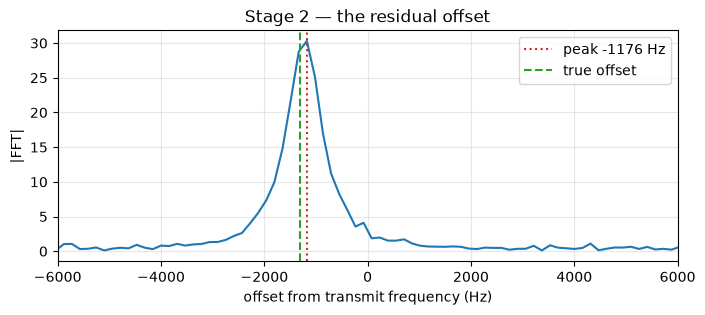

In [6]:
%matplotlib inline

# Cell 6 — Fine estimate: FFT peak offset

print("Cell 6 — Stage 2: FFT peak")
print("--------------------------")


def fft_offset_hz(rx, dwell_s):
    """Offset of the spectral peak, in Hz. Axis construction as in larmor_cal."""
    spectrum = np.fft.fftshift(np.fft.fft(rx))
    fft_bw = 1 / dwell_s                       # FULL span = 1/dwell
    axis = np.linspace(-fft_bw / 2, fft_bw / 2, num=rx.shape[0])
    return axis[np.argmax(np.abs(spectrum))], axis, np.abs(spectrum)


rx = acquire(coarse_f0, seed=7)
offset_hz, axis_hz, magnitude = fft_offset_hz(rx, DWELL_S)
fine_f0 = coarse_f0 + offset_hz / 1e6

print(f"Transmitting at   : {coarse_f0:.5f} MHz  (coarse estimate)")
print(f"Measured offset   : {offset_hz:+.1f} Hz")
print(f"Corrected f0      : {fine_f0:.5f} MHz")
print(f"True f0           : {F0_TRUE_MHZ:.5f} MHz")
print(f"Error             : {(fine_f0 - F0_TRUE_MHZ)*1e6:+.1f} Hz   (bin width {1/T_ADC_S:.1f} Hz)")
print()
print(f"Improvement over coarse: {abs(coarse_err):.0f} Hz -> {abs((fine_f0-F0_TRUE_MHZ)*1e6):.0f} Hz")

plt.figure(figsize=(8, 3))
plt.plot(axis_hz, magnitude)
plt.axvline(offset_hz, color="tab:red", ls=":", label=f"peak {offset_hz:+.0f} Hz")
plt.axvline((F0_TRUE_MHZ - coarse_f0) * 1e6, color="tab:green", ls="--", label="true offset")
plt.xlim(-6000, 6000)
plt.xlabel("offset from transmit frequency (Hz)"); plt.ylabel("|FFT|")
plt.grid(alpha=0.3); plt.legend(); plt.title("Stage 2 — the residual offset")
plt.show()

## Cell 7 — How good can this get?

The fine estimate cannot beat the bin width, `1 / T_adc`. This cell checks that claim
honestly: hide a range of true offsets, run the same estimator, and look at the errors.

There is also a **systematic** error hiding here, separate from the resolution limit, and
this cell measures it.

`larmor_cal` builds its frequency axis as `np.linspace(f_tx - bw/2, f_tx + bw/2, num=N)`.
That looks right and is off by half a bin. `np.linspace` with the default `endpoint=True`
includes *both* ends, giving spacing `bw/(N-1)`; the real FFT grid after `fftshift` runs from
`-bw/2` up to `+bw/2 - bin` and is **not** symmetric — for even `N` there is one more negative
frequency than positive. The exact axis is `np.fft.fftshift(np.fft.fftfreq(N, dwell))`.

The cell compares three estimators:

| Estimator | What it is |
| --- | --- |
| console axis | `linspace`, exactly as `larmor_cal` does it |
| exact axis | `np.fft.fftfreq` |
| exact + parabolic | sub-bin interpolation on the exact axis |

Watch the **mean** error, not just the spread: a bias shows up there and nowhere else. At
15.5 MHz half a bin is ~78 Hz, about 5 ppm — small, but it is a constant offset you cannot
average away, and it is free to fix.

Note also what fixing the axis does for the parabolic refinement. On the biased axis it looks
worthless; on the exact axis it cuts the worst-case error by roughly a factor of six, because
sub-bin interpolation can only correct binning error once the systematic offset is gone.

The other way to do better is a **longer readout**: resolution is `1/T_adc`, so doubling the
ADC duration halves the bin — until T2\* has decayed the echo and you are fitting noise.

Cell 7 — Accuracy check
-----------------------
FFT bin width : 156.2 Hz   (half a bin = 78.1 Hz)

  estimator                mean err   max |err|
  ---------------------------------------------
  console axis (linspace)     +78.4 Hz     152.9 Hz
  exact axis (fftfreq)        +0.0 Hz      81.2 Hz
  exact + parabolic           +0.0 Hz      13.5 Hz

Systematic bias from the linspace axis: +78.4 Hz  (half a bin is 78.1 Hz)
PASS: on the exact axis, error stays within one bin, as theory says it must.


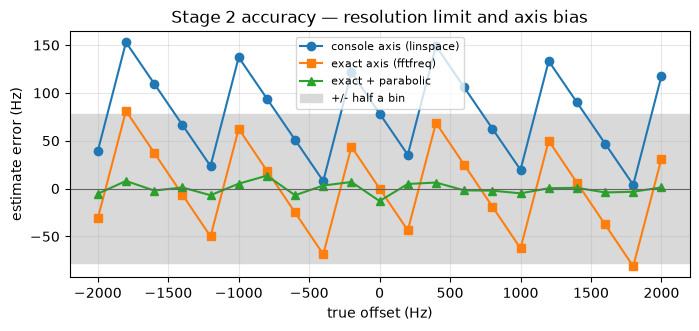

In [7]:
%matplotlib inline

# Cell 7 — Error against the resolution limit

print("Cell 7 — Accuracy check")
print("-----------------------")


def parabolic_refine(axis, magnitude):
    """Sub-bin peak position by fitting a parabola through the peak and its neighbours."""
    k = int(np.argmax(magnitude))
    if k == 0 or k == len(magnitude) - 1:
        return axis[k]
    a, b, c = magnitude[k - 1], magnitude[k], magnitude[k + 1]
    denom = a - 2 * b + c
    shift = 0.0 if denom == 0 else 0.5 * (a - c) / denom
    return axis[k] + shift * (axis[1] - axis[0])


bin_hz = 1 / T_ADC_S
true_offsets = np.linspace(-2000, 2000, 21)

exact_axis = np.fft.fftshift(np.fft.fftfreq(ADC_SAMPLES, DWELL_S))   # the correct grid

err_console, err_exact, err_refined = [], [], []
for i, want in enumerate(true_offsets):
    rx_i = acquire(F0_TRUE_MHZ - want / 1e6, seed=200 + i)
    mag = np.abs(np.fft.fftshift(np.fft.fft(rx_i)))
    _, console_axis, _ = fft_offset_hz(rx_i, DWELL_S)                # linspace, as larmor_cal
    k = int(np.argmax(mag))
    err_console.append(console_axis[k] - want)
    err_exact.append(exact_axis[k] - want)
    err_refined.append(parabolic_refine(exact_axis, mag) - want)

err_console = np.array(err_console)
err_exact = np.array(err_exact)
err_refined = np.array(err_refined)

print(f"FFT bin width : {bin_hz:.1f} Hz   (half a bin = {bin_hz/2:.1f} Hz)")
print()
print(f"  {'estimator':<22s} {'mean err':>10s} {'max |err|':>11s}")
print("  " + "-" * 45)
for label, e in (("console axis (linspace)", err_console),
                 ("exact axis (fftfreq)", err_exact),
                 ("exact + parabolic", err_refined)):
    print(f"  {label:<22s} {e.mean():+9.1f} Hz {np.abs(e).max():9.1f} Hz")

print()
bias = err_console.mean() - err_exact.mean()
print(f"Systematic bias from the linspace axis: {bias:+.1f} Hz  (half a bin is {bin_hz/2:.1f} Hz)")
if np.abs(err_exact).max() <= bin_hz:
    print("PASS: on the exact axis, error stays within one bin, as theory says it must.")

plt.figure(figsize=(8, 3.2))
plt.plot(true_offsets, err_console, "o-", label="console axis (linspace)")
plt.plot(true_offsets, err_exact, "s-", label="exact axis (fftfreq)")
plt.plot(true_offsets, err_refined, "^-", label="exact + parabolic")
plt.axhspan(-bin_hz / 2, bin_hz / 2, color="0.85", label="+/- half a bin")
plt.axhline(0, color="0.4", lw=0.8)
plt.xlabel("true offset (Hz)"); plt.ylabel("estimate error (Hz)")
plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.title("Stage 2 accuracy — resolution limit and axis bias")
plt.show()

## Cell 8 — A units trap worth knowing about

The two f0 estimators in this repository do not agree, and the difference is not cosmetic.

`calibration.py` (`larmor_cal`) builds its axis from the **dwell time**:

```python
fft_bw = 1 / (rx_t)                  # rx_t = dwell -> full span
```

`console/sequences/adj_frequency.py` builds its axis from the **total ADC duration**, and
takes `argmax` of an unshifted FFT while subtracting `N/2` as though it had been shifted:

```python
adc_time   = self.param_ADC_duration
X          = np.fft.fft(x)           # not fftshift-ed
fmax       = 1 / adc_time / 2
f          = np.linspace(-fmax, fmax, rxd.shape[0])
del_f      = f[-1] - f[-2]
freq_offset = (np.argmax(np.abs(X)) - int(0.5 * rxd.shape[0])) * del_f
```

Two problems compound: the span is `1/T_adc` instead of `1/dwell`, which is a factor of `N`
too narrow, and the missing `fftshift` puts the peak at the wrong index.

The cell below runs both on identical data with a known answer. Do not take my word for it —
read the numbers.

**If you are chasing an `adj_frequency` scan that reports an implausibly small correction,
this is where to look.** `larmor_cal` is the implementation to trust.

In [8]:
# Cell 8 — Compare the two estimators on identical data

print("Cell 8 — Two estimators, one signal")
print("-----------------------------------")

KNOWN_OFFSET_HZ = 1200.0
f_tx = F0_TRUE_MHZ - KNOWN_OFFSET_HZ / 1e6
rx_test = acquire(f_tx, seed=42)

# calibration.py / larmor_cal
est_cal, _, _ = fft_offset_hz(rx_test, DWELL_S)

# adj_frequency.py, transcribed
adc_time = t[-1]
X = np.fft.fft(rx_test)
fmax = 1 / adc_time / 2
f_axis = np.linspace(-fmax, fmax, rx_test.shape[0])
del_f = f_axis[-1] - f_axis[-2]
est_adj = (np.argmax(np.abs(X)) - int(0.5 * rx_test.shape[0])) * del_f

print(f"True offset                    : {KNOWN_OFFSET_HZ:+9.1f} Hz")
print(f"calibration.py  (larmor_cal)   : {est_cal:+9.1f} Hz   error {est_cal-KNOWN_OFFSET_HZ:+8.1f} Hz")
print(f"adj_frequency.py               : {est_adj:+9.1f} Hz   error {est_adj-KNOWN_OFFSET_HZ:+8.1f} Hz")
print()
print(f"Span used by calibration.py    : 1/dwell = {1/DWELL_S:10.1f} Hz")
print(f"Span used by adj_frequency.py  : 1/T_adc = {1/T_ADC_S:10.1f} Hz")
print(f"Ratio                          : {(1/DWELL_S)/(1/T_ADC_S):10.0f}x  (= ADC_samples = {ADC_SAMPLES})")
print()
if abs(est_cal - KNOWN_OFFSET_HZ) <= 2 * (1 / T_ADC_S):
    print("larmor_cal recovers the offset to within a bin or two.")
if abs(est_adj - KNOWN_OFFSET_HZ) > 5 * (1 / T_ADC_S):
    print("adj_frequency.py does not. Prefer larmor_cal, and report this upstream.")

Cell 8 — Two estimators, one signal
-----------------------------------
True offset                    :   +1200.0 Hz
calibration.py  (larmor_cal)   :   +1333.3 Hz   error   +133.3 Hz
adj_frequency.py               :     -73.8 Hz   error  -1273.8 Hz

Span used by calibration.py    : 1/dwell =    40000.0 Hz
Span used by adj_frequency.py  : 1/T_adc =      156.2 Hz
Ratio                          :        256x  (= ADC_samples = 256)

larmor_cal recovers the offset to within a bin or two.
adj_frequency.py does not. Prefer larmor_cal, and report this upstream.


## Cell 9 — Doing this on hardware

On a scanner, stages 1 and 2 are two function calls. Neither runs here — there is no
Red Pitaya — so this cell prints them rather than executing.

```python
from external.seq.adjustments_acq.calibration import larmor_step_search, larmor_cal

# Stage 1 -- coarse, from the stored value
coarse_f0, data = larmor_step_search(
    seq_file=seq_path,
    step_search_center=cfg.LARMOR_FREQ,
    steps=10, step_bw_MHz=5e-3,
    delay_s=1, dummy_scans=3,
)

# Stage 2 -- refine
f0, data = larmor_cal(
    seq_file=seq_path,
    larmor_start=coarse_f0,
    iterations=10, delay_s=1,
)
```

Then **persist it**, or the next scan starts from the old value again:

```python
from sequences.common.util import reading_json_parameter, writing_json_parameter

config = reading_json_parameter()
config.rf_parameters.larmor_frequency_MHz = f0
writing_json_parameter(config_data=config)
```

Two practical notes from the console's own defaults:

- **`delay_s` exists for a reason.** Spins need to recover between measurements; sweeping
  faster than T1 gives a saturated, misleading SNR curve.
- **`dummy_scans`** run the sequence without recording, to reach steady state before the
  measurements that count.

In [9]:
# Cell 9 — Where the answer goes (nothing here touches hardware)

print("Cell 9 — Persisting the calibration")
print("-----------------------------------")

print("Config file that holds f0:")
print("   ", config_path)
print()
print("Field:  rf_parameters.larmor_frequency_MHz")
print()
print(f"  stored value  : {LARMOR_FREQ_MHZ:.5f} MHz")
print(f"  this notebook : {fine_f0:.5f} MHz  (simulated)")
print(f"  difference    : {(fine_f0 - LARMOR_FREQ_MHZ)*1e6:+.0f} Hz")
print()
print("Not written -- these numbers came from a simulation, and writing them would")
print("corrupt a real calibration. On a scanner, writing_json_parameter() does it.")
print()
print("Artifacts from this notebook:")
for p in sorted(work_dir.glob("*.seq")):
    print(f"    {p.name:24s} {p.stat().st_size:8d} bytes")

Cell 9 — Persisting the calibration
-----------------------------------
Config file that holds f0:
    /home/jonathanmartin/Documents/postdoc-projects/DIY_MRI/adelpha/console/notebooks/f0_output/mri4all/config/config_acq.json

Field:  rf_parameters.larmor_frequency_MHz

  stored value  : 15.52000 MHz
  this notebook : 15.52382 MHz  (simulated)
  difference    : +3824 Hz

Not written -- these numbers came from a simulation, and writing them would
corrupt a real calibration. On a scanner, writing_json_parameter() does it.

Artifacts from this notebook:
    adj_frequency.seq            1255 bytes


## What to take away

- **f0 is a measurement with a shelf life**, not a constant. On a permanent-magnet system it
  tracks temperature, so it is the first scan of a session and worth repeating after the
  magnet has been working.
- **Two stages, because they do different jobs.** A coarse SNR sweep finds the peak at all;
  an FFT of the echo lands on it. The sweep is limited by its step size, the FFT by `1/T_adc`.
- **The echo must sit in the middle of the readout** for the console's noise estimate to
  mean anything. This is a property of the SNR metric, not an accident of the sequence.
- **Units decide whether the answer is right.** Full FFT span is `1/dwell`; bin width is
  `1/T_adc`. Cell 8 shows what confusing them costs.
- **Build the frequency axis with `np.fft.fftfreq`, not `linspace`.** Cell 7 measures the
  half-bin systematic bias that `linspace(-bw/2, bw/2, N)` introduces — ~78 Hz here, constant,
  and not something averaging removes.
- **Persist the result**, or the next scan starts from the stale value.

### Where this touches Adelpha

The digital twin models the same coupling this notebook exploits. `dtam`'s settings carry
`thermal_b0_coupling_hz_per_c` — an expected f0 shift per degree of magnet temperature — plus
`magnet_drift_warning_hz_per_min` thresholds. A measured f0 is ground truth for that model:
if the twin predicts a drift and the next `adj_frequency` disagrees, one of the two is wrong,
and that discrepancy is exactly the sort of thing the twin exists to surface.

### Things to try

1. Change `F0_TRUE_MHZ` in Cell 4 and rerun. Both stages should still find it, provided it
   stays inside the sweep.
2. Move it **outside** the sweep in Cell 5 and watch the coarse search confidently return the
   wrong answer. This is what a too-narrow search looks like in real life.
3. Raise `NOISE_SIGMA` until the SNR curve stops having an obvious peak. That is your
   detection limit, and on a real system it is why a bad coil or a noisy environment makes f0
   unfindable before it makes images bad.
4. Double `ADC_DURATION_US` in Cell 3 and rerun Cell 7. The bin halves and the error should
   follow — until you exceed T2\*, at which point extra samples add only noise.